In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
filepath = '/content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_datasetB.xlsx'

In [ ]:
!pip install pandas openpyxl

In [ ]:
import pandas as pd
import re

In [ ]:
with open(filepath, 'r', encoding='utf-8') as file:
    df = pd.read_excel(filepath)

/usr/local/lib/python3.11/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


# Limpieza de texto

In [ ]:
#Funciones de limpieza de texto
def clean_excel_text(text):
    if pd.isnull(text):  # Manejar valores nulos
        return ""
    # Remover menciones (@usuario)
    text = re.sub(r"@\w+", "", text)
    # Remover URLs
    text = re.sub(r"http\S+", "", text)
    # Eliminar caracteres especiales (solo mantener alfanuméricos y espacios)
    text = re.sub(r"[^\w\s]", "", text)
    # Quitar espacios extra
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Aplicar la limpieza a la columna 'text'
df["text_cleaned"] = df["text"].apply(clean_excel_text)

# Mostrar una vista previa de los datos limpios
print(df[["text", "text_cleaned"]].head())

# Guardar los datos limpios en un nuevo archivo Excel
output_file = "/content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_clean_datasetB.xlsx"
df.to_excel(output_file, index=False)

print(f"Archivo limpio guardado en {output_file}")


                                                text  \
0                  @Meryglesias Igual para ti Mery!!   
1  Mi padre será funcionario de casilla y ya está...   
2  @NachoRgz @XochitlGalvez Pues yo no veo ese fe...   
3  @alexandraalvis5 Quedamos https://t.co/GnssADVFfw   
4                               @oraciondiaria_ Amén   

                                        text_cleaned  
0                                 Igual para ti Mery  
1  Mi padre será funcionario de casilla y ya está...  
2  Pues yo no veo ese fervor por la gárgola de Cl...  
3                                           Quedamos  
4                                               Amén  
Archivo limpio guardado en /content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_clean_datasetB.xlsx


# Nube de palabras

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

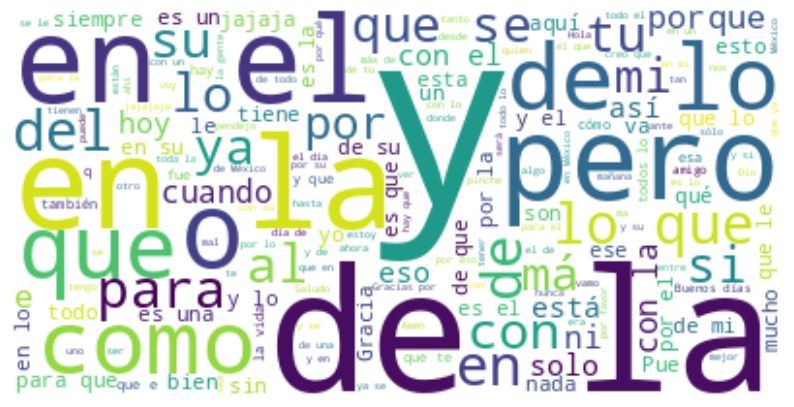

In [ ]:
# Crear la nube de palabras con la columna text_cleaned
long_string = ' '.join(df['text_cleaned'].values)  # Unir todo el texto limpio

# Configurar el objeto WordCloud
wordcloud = WordCloud(
    background_color="white",
    max_words=70000,
    contour_width=3,
    contour_color='steelblue'
)

# Generar la nube de palabras
wordcloud.generate(long_string)

# Visualizar la nube de palabras
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()


In [ ]:
import nltk
nltk.download('punkt') #Tokenizer
nltk.download('wordnet') #Lemmatizer
nltk.download('stopwords') #Stopwords
nltk.download('averaged_perceptron_tagger')
nltk.download('universal_tagset')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


In [ ]:
import spacy

In [ ]:
!pip install --upgrade --force-reinstall gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.2/83.2 kB 6.9 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: smart-open
    Found existing installation: smart-open 7.1.0
    Uninstalling smart-open-7.1.0:
      Successfully uninstal

In [ ]:
!pip install --upgrade numpy
!pip install --upgrade --force-reinstall gensim

  Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached numpy-2.2.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.4 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.2.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.2.4 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.2.4 which is incompatible.
  Using cached gensim-4.3.3-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (8.1 kB)
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (

# Eliminación de stopwords

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
import spacy

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
from gensim.models import Word2Vec
import gensim.downloader

In [ ]:
stop_words = set(stopwords.words("english"))
stopwords_es = set(stopwords.words('spanish'))

## Tokenización

In [ ]:
#Tokenización
def tokenize_text(text):
    return word_tokenize(text, language='spanish')

df['tokens'] = df['text_cleaned'].apply(tokenize_text)

In [ ]:
# Mostrar resultados
print(df[['text_cleaned', 'tokens']].head())

                                        text_cleaned  \
0                                 Igual para ti Mery   
1  Mi padre será funcionario de casilla y ya está...   
2  Pues yo no veo ese fervor por la gárgola de Cl...   
3                                           Quedamos   
4                                               Amén   

                                              tokens  
0                            [Igual, para, ti, Mery]  
1  [Mi, padre, será, funcionario, de, casilla, y,...  
2  [Pues, yo, no, veo, ese, fervor, por, la, gárg...  
3                                         [Quedamos]  
4                                             [Amén]  


In [ ]:
# Explotar los tokens para tener uno por fila
tokens_df = df.explode('tokens')[['tokens']].dropna()

output_tokens = "/content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_datasetb-tokens_list.csv"
tokens_df.to_csv(output_tokens, index=False, encoding='utf-8')

print(f"Lista de tokens guardada en: {output_tokens}")

Lista de tokens guardada en: /content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_datasetb-tokens_list.csv


In [ ]:
# Guardar dataframe con tokens
output_csv = "/content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_datasetb_tokens.csv"
df.to_csv(output_csv, index=False, encoding='utf-8')

print(f"Archivo con tokens guardado en: {output_csv}")

Archivo con tokens guardado en: /content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_datasetb_tokens.csv


## Filtrado de palabras

In [ ]:
# Función de filtrado de stopwords
def remove_stopwords(text, language='spanish'):
    stopwords_set = set(stopwords.words(language))
    tokens = word_tokenize(text.lower(), language=language)

    # Filtrado de stopwords y palabras con menos de 3 caracteres
    filtered_words = [word for word in tokens if word not in stopwords_set and len(word) > 2]
    return " ".join(filtered_words)  # Devuelve el texto unido

In [ ]:
# Aplicar limpieza
df["text_cleaned"] = df["text"].apply(clean_excel_text)

# Aplicar filtrado de stopwords a la columna limpia
df["text_filtered"] = df["text_cleaned"].apply(remove_stopwords)

# Mostrar resultados
print(df[["text", "text_cleaned", "text_filtered"]].head())


                                                text  \
0                  @Meryglesias Igual para ti Mery!!   
1  Mi padre será funcionario de casilla y ya está...   
2  @NachoRgz @XochitlGalvez Pues yo no veo ese fe...   
3  @alexandraalvis5 Quedamos https://t.co/GnssADVFfw   
4                               @oraciondiaria_ Amén   

                                        text_cleaned  \
0                                 Igual para ti Mery   
1  Mi padre será funcionario de casilla y ya está...   
2  Pues yo no veo ese fervor por la gárgola de Cl...   
3                                           Quedamos   
4                                               Amén   

                                text_filtered  
0                                  igual mery  
1  padre funcionario casilla listo democracia  
2       pues veo fervor gárgola claudia andes  
3                                    quedamos  
4                                        amén  


In [ ]:
output_path = "/content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_datasetb_filtered.csv"
df.to_csv(output_path, index=False, encoding='utf-8')
print(f"Dataset guardado en: {output_path}")

Dataset guardado en: /content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/CB_datasetb_filtered.csv


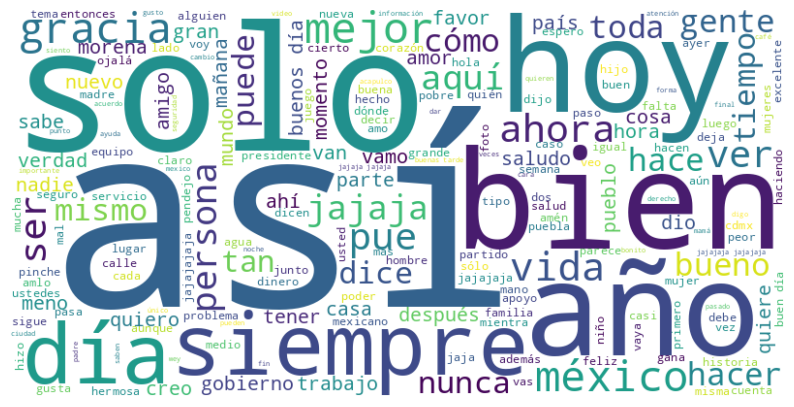

Nube de palabras guardada en: /content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/wordcloud-datasetb.png


In [ ]:
# Obtener el texto filtrado y unirlo en una sola cadena
words_filter = ' '.join(df["text_filtered"].dropna())  # Usar la columna sin stopwords

# Configurar la nube de palabras
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='viridis',
    stopwords=set(stopwords.words('spanish')))

# Generar la nube
wordcloud.generate(words_filter)

# Mostrar la nube
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Ocultar ejes
plt.show()

output_image = "/content/drive/My Drive/DATASET_TESIS_CIC/DATASET_B/wordcloud-datasetb.png"
wordcloud.to_file(output_image)
print(f"Nube de palabras guardada en: {output_image}")


In [ ]:
# Añadir palabras stopwords que aún aparecen
extra_stopwords = {"así", "vez", "cómo", "sólo", "solo", "amlo", "hacer", "hace", "pue", "hace", "toda", "dijo", "aquí", "dio"}
stopwords_es.update(extra_stopwords)

In [ ]:
def remove_stopwords(text, stopwords_list):
    tokens = word_tokenize(text.lower(), language='spanish')
    filtered_words = [word for word in tokens if word not in stopwords_list and len(word) > 2]
    return " ".join(filtered_words)

# Aplicar filtro actualizado
df["text_filtered"] = df["text_cleaned"].apply(remove_stopwords, stopwords_list=stopwords_es)

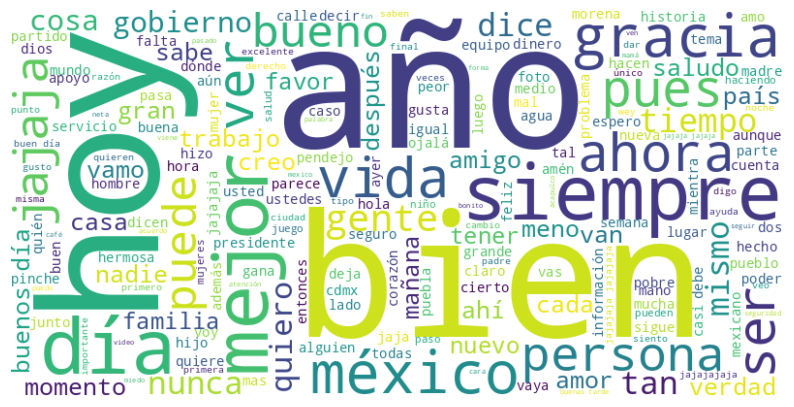

In [ ]:
# Creación de nueva nube de palabras con el texto filtrado y ajustado a palabras

texto_filtrado = ' '.join(df["text_filtered"].dropna())
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=stopwords_es
).generate(texto_filtrado)

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()